<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/Diya-ASSGN-2/CatBoost_ML_Model_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Install CatBoost
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.9 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

from catboost import CatBoostClassifier, CatBoostRegressor  # use Regressor if your target is numeric (LOS)

# Numeric LOS Prediction Model


In [4]:
# Load the preprocessed dataset
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/model_df_clf_v2.feather')  #change to your actual file name

print(df.shape)
df.head()


Mounted at /content/drive
(4238636, 20)


,health_service_area,hospital_county,facility_id,age_group,zip_code,gender,race,ethnicity,length_of_stay,admission_type,ccsr_dx_code,ccsr_px_code,apr_drg_code,apr_mdc_code,apr_severity_code,apr_mortality_risk,apr_med_surg_desc,num_payment_types,payment_type,los_category
0,New York City,Bronx,3058,50-69,104,F,Other Race,Spanish/Hispanic,1,Emergency,NEO074,ADM021,861,23,2,Moderate,Medical,1,Medicaid,Short
1,New York City,Bronx,1168,30-49,104,M,Black/African American,Not Span/Hispanic,4,Emergency,CIR013,ADM021,134,4,2,Minor,Medical,1,Medicaid,Moderate
2,New York City,Bronx,3058,50-69,104,M,Other Race,Not Span/Hispanic,4,Emergency,INF002,ADM019,720,18,4,Extreme,Medical,2,"Medicaid, Medicare",Moderate
3,New York City,Bronx,1169,18-29,104,M,Black/African American,Not Span/Hispanic,5,Emergency,BLD005,No procedure,662,16,2,Minor,Medical,1,Medicaid,Moderate
4,New York City,Bronx,1169,50-69,104,F,Other Race,Spanish/Hispanic,3,Emergency,INF002,ADM019,720,18,3,Moderate,Medical,2,"Medicaid, Medicare",Moderate


In [5]:
from sklearn.model_selection import train_test_split

# 1. Target column
TARGET_COL = "length_of_stay"

# 2. Columns we NEVER want as features
#    (you asked to KEEP zip_code, so it's NOT here)
always_drop = ["los_log", "los_yj"]

# 3. Column that leaks the answer for numeric LOS
leak_cols = ["los_category"]

# Filter to only the columns that actually exist in df
drop_cols = [c for c in always_drop + leak_cols if c in df.columns]

print("Dropping from features:", drop_cols)

# 4. Build X and y
X = df.drop(columns=drop_cols + [TARGET_COL])
y = df[TARGET_COL].astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

# 5. Categorical columns based on what you printed
categorical_cols = [
    "health_service_area",
    "hospital_county",
    "facility_id",
    "age_group",
    "zip_code",
    "gender",
    "race",
    "ethnicity",
    "admission_type",
    "ccsr_dx_code",
    "ccsr_px_code",
    "apr_drg_code",
    "apr_mdc_code",
    "apr_severity_code",
    "apr_mortality_risk",
    "apr_med_surg_desc",
    "payment_type",
    # "los_category"   #NOT used as feature for numeric LOS
]

# CatBoost categorical features = intersection with X's columns
cat_features = [c for c in categorical_cols if c in X.columns]

print("CatBoost categorical features:", cat_features)

# 6. Small sample (1%) to show proof of concept
X_small, _, y_small, _ = train_test_split(
    X, y,
    train_size=0.1,
    random_state=42
    # no stratify because y is numeric
)

print("X_small shape:", X_small.shape)
print("y_small shape:", y_small.shape)


Dropping from features: ['los_category']
X shape: (4238636, 18)
y shape: (4238636,)
CatBoost categorical features: ['health_service_area', 'hospital_county', 'facility_id', 'age_group', 'zip_code', 'gender', 'race', 'ethnicity', 'admission_type', 'ccsr_dx_code', 'ccsr_px_code', 'apr_drg_code', 'apr_mdc_code', 'apr_severity_code', 'apr_mortality_risk', 'apr_med_surg_desc', 'payment_type']
X_small shape: (423863, 18)
y_small shape: (423863,)


In [6]:
# Replace only Python None and string "None" with "Missing" in all object (potential categorical) columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace({None: "Missing", "None": "Missing"})

In [8]:
from catboost import CatBoostRegressor

X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_small, y_small,
    test_size=0.3,
    random_state=0
)

model_small = CatBoostRegressor(
    task_type='GPU',
    devices='0',
    depth=6,
    learning_rate=0.1,
    iterations=500,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=50
)

model_small.fit(
    X_train_small,
    y_train_small,
    cat_features=cat_features,
    eval_set=(X_test_small, y_test_small),
    use_best_model=True
)


0:	learn: 8.5788650	test: 8.3835548	best: 8.3835548 (0)	total: 61.3ms	remaining: 30.6s
50:	learn: 6.9545713	test: 6.7355605	best: 6.7355605 (50)	total: 1.97s	remaining: 17.3s
100:	learn: 6.8228634	test: 6.6363672	best: 6.6363672 (100)	total: 3.91s	remaining: 15.4s
150:	learn: 6.7588415	test: 6.6021343	best: 6.6021343 (150)	total: 5.99s	remaining: 13.9s
200:	learn: 6.7143834	test: 6.5801602	best: 6.5801602 (200)	total: 11.1s	remaining: 16.6s
250:	learn: 6.6796598	test: 6.5685497	best: 6.5685497 (250)	total: 13.1s	remaining: 13s
300:	learn: 6.6539395	test: 6.5611789	best: 6.5609389 (298)	total: 15s	remaining: 9.94s
350:	learn: 6.6277046	test: 6.5510538	best: 6.5510538 (350)	total: 17s	remaining: 7.21s
400:	learn: 6.6007797	test: 6.5410975	best: 6.5410068 (398)	total: 18.9s	remaining: 4.67s
450:	learn: 6.5810748	test: 6.5376329	best: 6.5375589 (448)	total: 22.2s	remaining: 2.41s
499:	learn: 6.5606393	test: 6.5337177	best: 6.5337177 (499)	total: 24.1s	remaining: 0us
bestTest = 6.533717741


In [9]:
#Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# --- Predictions ---
y_train_pred_small = model_small.predict(X_train_small)
y_test_pred_small  = model_small.predict(X_test_small)

# --- Model metrics (train) ---
mse_train  = mean_squared_error(y_train_small, y_train_pred_small)
rmse_train = np.sqrt(mse_train)
mae_train  = mean_absolute_error(y_train_small, y_train_pred_small)
r2_train   = r2_score(y_train_small, y_train_pred_small)

# --- Model metrics (test) ---
mse_test  = mean_squared_error(y_test_small, y_test_pred_small)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test_small, y_test_pred_small)
r2_test   = r2_score(y_test_small, y_test_pred_small)

# --- Baseline on test set: always predict mean training LOS ---
baseline_pred_test = np.full_like(y_test_small, y_train_small.mean(), dtype=float)

mse_base  = mean_squared_error(y_test_small, baseline_pred_test)
rmse_base = np.sqrt(mse_base)
mae_base  = mean_absolute_error(y_test_small, baseline_pred_test)
r2_base   = r2_score(y_test_small, baseline_pred_test)

# --- print everything ---
print("===== Small CatBoost LOS Model (Numeric) =====")
print("Train MSE : {:.3f}".format(mse_train))
print("Train RMSE: {:.3f}".format(rmse_train))
print("Train MAE : {:.3f}".format(mae_train))
print("Train R²  : {:.3f}".format(r2_train))
print()
print("Test  MSE : {:.3f}".format(mse_test))
print("Test  RMSE: {:.3f}".format(rmse_test))
print("Test  MAE : {:.3f}".format(mae_test))
print("Test  R²  : {:.3f}".format(r2_test))
print()
print("===== Baseline (mean LOS on train, evaluated on test) =====")
print("Baseline MSE : {:.3f}".format(mse_base))
print("Baseline RMSE: {:.3f}".format(rmse_base))
print("Baseline MAE : {:.3f}".format(mae_base))
print("Baseline R²  : {:.3f}".format(r2_base))


===== Small CatBoost LOS Model (Numeric) =====
Train MSE : 43.093
Train RMSE: 6.565
Train MAE : 3.025
Train R²  : 0.446

Test  MSE : 42.689
Test  RMSE: 6.534
Test  MAE : 3.045
Test  R²  : 0.427

===== Baseline (mean LOS on train, evaluated on test) =====
Baseline MSE : 74.560
Baseline RMSE: 8.635
Baseline MAE : 4.599
Baseline R²  : -0.000


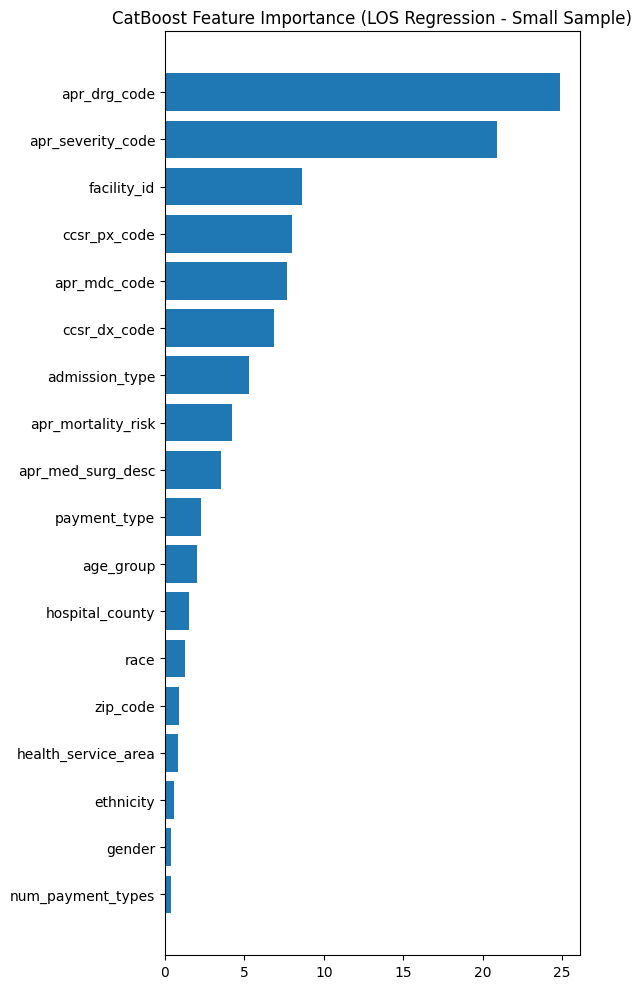

In [11]:
# OPTIONAL: Feature Importance for the small CatBoost model
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the trained small model
feature_importances = model_small.get_feature_importance()
feature_names = X_train_small.columns

# Sort by importance
sorted_idx = np.argsort(feature_importances)

plt.figure(figsize=(6, 10))
plt.barh(feature_names[sorted_idx], feature_importances[sorted_idx])
plt.title("CatBoost Feature Importance (LOS Regression - Small Sample)")
plt.tight_layout()
plt.show()


# Socioeconomic Factors Effect on Numeric LOS


In [18]:
# socio-economic features
soc_cols = ["zip_code", "race", "ethnicity", "payment_type"]

# keep only ones that actually exist in X_train_small
soc_cols = [c for c in soc_cols if c in X_train_small.columns]
print("Socio-economic columns:", soc_cols)


Socio-economic columns: ['zip_code', 'race', 'ethnicity', 'payment_type']


In [19]:
#Model B Inputs
# Drop socio-economic features ONLY from the feature matrices
X_train_small_nosoc = X_train_small.drop(columns=soc_cols)
X_test_small_nosoc  = X_test_small.drop(columns=soc_cols)

# New categorical feature list for this model
cat_features_nosoc = [c for c in cat_features if c in X_train_small_nosoc.columns]

print("Shape with socio features   :", X_train_small.shape)
print("Shape WITHOUT socio features:", X_train_small_nosoc.shape)
print("Cat features (no socio):", cat_features_nosoc)


Shape with socio features   : (296704, 18)
Shape WITHOUT socio features: (296704, 14)
Cat features (no socio): ['health_service_area', 'hospital_county', 'facility_id', 'age_group', 'gender', 'admission_type', 'ccsr_dx_code', 'ccsr_px_code', 'apr_drg_code', 'apr_mdc_code', 'apr_severity_code', 'apr_mortality_risk', 'apr_med_surg_desc']


In [20]:
#Train Model B
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model_small_nosoc = CatBoostRegressor(
    depth=6,
    learning_rate=0.1,
    iterations=500,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=50,
    task_type="GPU",
    devices="0"
)

model_small_nosoc.fit(
    X_train_small_nosoc,
    y_train_small,
    cat_features=cat_features_nosoc,
    eval_set=(X_test_small_nosoc, y_test_small),
    use_best_model=True
)


0:	learn: 8.5761341	test: 8.3808082	best: 8.3808082 (0)	total: 44.1ms	remaining: 22s
50:	learn: 6.9432116	test: 6.7231081	best: 6.7231081 (50)	total: 1.73s	remaining: 15.3s
100:	learn: 6.8229664	test: 6.6305062	best: 6.6305062 (100)	total: 3.38s	remaining: 13.4s
150:	learn: 6.7678391	test: 6.6025833	best: 6.6024574 (149)	total: 5.1s	remaining: 11.8s
200:	learn: 6.7181426	test: 6.5788299	best: 6.5788299 (200)	total: 6.8s	remaining: 10.1s
250:	learn: 6.6782849	test: 6.5625799	best: 6.5625799 (250)	total: 8.51s	remaining: 8.44s
300:	learn: 6.6514717	test: 6.5546460	best: 6.5546025 (297)	total: 10.5s	remaining: 6.94s
350:	learn: 6.6222742	test: 6.5442071	best: 6.5442071 (350)	total: 13.3s	remaining: 5.65s
400:	learn: 6.5957867	test: 6.5386459	best: 6.5385930 (396)	total: 15s	remaining: 3.71s
450:	learn: 6.5724636	test: 6.5334785	best: 6.5334785 (450)	total: 16.7s	remaining: 1.82s
499:	learn: 6.5504789	test: 6.5283576	best: 6.5276706 (494)	total: 18.4s	remaining: 0us
bestTest = 6.52767062
b

In [21]:
# Predictions for Model B
y_train_pred_nosoc = model_small_nosoc.predict(X_train_small_nosoc)
y_test_pred_nosoc  = model_small_nosoc.predict(X_test_small_nosoc)

mse_train_nosoc  = mean_squared_error(y_train_small, y_train_pred_nosoc)
rmse_train_nosoc = np.sqrt(mse_train_nosoc)
mae_train_nosoc  = mean_absolute_error(y_train_small, y_train_pred_nosoc)
r2_train_nosoc   = r2_score(y_train_small, y_train_pred_nosoc)

mse_test_nosoc  = mean_squared_error(y_test_small, y_test_pred_nosoc)
rmse_test_nosoc = np.sqrt(mse_test_nosoc)
mae_test_nosoc  = mean_absolute_error(y_test_small, y_test_pred_nosoc)
r2_test_nosoc   = r2_score(y_test_small, y_test_pred_nosoc)


print("\n=== Model B: WITHOUT socio-economic features ===")
print(f"Train RMSE: {rmse_train_nosoc:.3f}")
print(f"Train MAE : {mae_train_nosoc:.3f}")
print(f"Train R²  : {r2_train_nosoc:.3f}")
print()
print(f"Test RMSE : {rmse_test_nosoc:.3f}")
print(f"Test MAE  : {mae_test_nosoc:.3f}")
print(f"Test R²   : {r2_test_nosoc:.3f}")



=== Model B: WITHOUT socio-economic features ===
Train RMSE: 6.561
Train MAE : 3.018
Train R²  : 0.447

Test RMSE : 6.528
Test MAE  : 3.037
Test R²   : 0.429


# Categorical LOS Prediction Model

In [23]:
from sklearn.model_selection import train_test_split

# Classification target
TARGET_CLS = "los_category"

# Make a copy for classification
df_cls = df.copy()

# Columns that leak the answer for classification
leak_cols_cls = ["length_of_stay", "los_log", "los_yj"]
leak_cols_cls = [c for c in leak_cols_cls if c in df_cls.columns]

print("Dropping from features for classification:", leak_cols_cls + [TARGET_CLS])

# Features and target for classification
X_cls = df_cls.drop(columns=[TARGET_CLS] + leak_cols_cls)
y_cls = df_cls[TARGET_CLS].astype(str)

print("X_cls shape:", X_cls.shape)
print("y_cls shape:", y_cls.shape)

# Categorical features for CatBoost (object or category dtypes)
cat_features_cls = X_cls.select_dtypes(include=['object', 'category']).columns.tolist()
print("CatBoost categorical features (classification):", cat_features_cls)

# Small sample (1%) with stratification since y is categorical
X_small_cls, _, y_small_cls, _ = train_test_split(
    X_cls, y_cls,
    train_size=0.1,
    random_state=42,
    stratify=y_cls
)

print("X_small_cls shape:", X_small_cls.shape)
print("y_small_cls shape:", y_small_cls.shape)


Dropping from features for classification: ['length_of_stay', 'los_category']
X_cls shape: (4238636, 18)
y_cls shape: (4238636,)
CatBoost categorical features (classification): ['health_service_area', 'hospital_county', 'facility_id', 'age_group', 'zip_code', 'gender', 'race', 'ethnicity', 'admission_type', 'ccsr_dx_code', 'ccsr_px_code', 'apr_drg_code', 'apr_mdc_code', 'apr_severity_code', 'apr_mortality_risk', 'apr_med_surg_desc', 'payment_type']
X_small_cls shape: (423863, 18)
y_small_cls shape: (423863,)


In [24]:
#Running Model
from catboost import CatBoostClassifier

# Train/test split on the small classification sample
X_train_small_cls, X_test_small_cls, y_train_small_cls, y_test_small_cls = train_test_split(
    X_small_cls, y_small_cls,
    test_size=0.3,
    random_state=0,
    stratify=y_small_cls
)

cls_model_small = CatBoostClassifier(
    task_type='GPU',
    devices='0',
    depth=6,
    learning_rate=0.1,
    iterations=500,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=50
)

cls_model_small.fit(
    X_train_small_cls,
    y_train_small_cls,
    cat_features=cat_features_cls,
    eval_set=(X_test_small_cls, y_test_small_cls),
    use_best_model=True
)


0:	learn: 0.4888104	test: 0.4885852	best: 0.4885852 (0)	total: 21.3ms	remaining: 10.6s
50:	learn: 0.5413375	test: 0.5443814	best: 0.5443814 (50)	total: 835ms	remaining: 7.35s
100:	learn: 0.5541179	test: 0.5538971	best: 0.5538971 (100)	total: 1.58s	remaining: 6.26s
150:	learn: 0.5585735	test: 0.5570899	best: 0.5571764 (148)	total: 2.3s	remaining: 5.32s
200:	learn: 0.5622877	test: 0.5591425	best: 0.5591425 (200)	total: 3.02s	remaining: 4.49s
250:	learn: 0.5643672	test: 0.5603693	best: 0.5604794 (244)	total: 3.72s	remaining: 3.69s
300:	learn: 0.5661366	test: 0.5613130	best: 0.5613681 (285)	total: 4.43s	remaining: 2.93s
350:	learn: 0.5677106	test: 0.5615725	best: 0.5617534 (313)	total: 5.12s	remaining: 2.17s
400:	learn: 0.5695879	test: 0.5622882	best: 0.5623825 (399)	total: 5.81s	remaining: 1.43s
450:	learn: 0.5712495	test: 0.5625791	best: 0.5627128 (412)	total: 6.98s	remaining: 758ms
499:	learn: 0.5726111	test: 0.5627836	best: 0.5629802 (496)	total: 9.64s	remaining: 0us
bestTest = 0.56298

In [25]:
#Metrics
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Predictions
y_train_pred_cls = cls_model_small.predict(X_train_small_cls)
y_test_pred_cls  = cls_model_small.predict(X_test_small_cls)

print("===== Small CatBoost Classification Model (los_category) =====")
print("Train accuracy:", accuracy_score(y_train_small_cls, y_train_pred_cls))
print("Test accuracy :", accuracy_score(y_test_small_cls, y_test_pred_cls))
print()
print("Test classification report:")
print(classification_report(y_test_small_cls, y_test_pred_cls))

# Baseline: always predict the most frequent class in training data
from collections import Counter
most_common_class = Counter(y_train_small_cls).most_common(1)[0][0]
baseline_pred_test = np.full_like(y_test_small_cls, most_common_class, dtype=object)

baseline_acc = accuracy_score(y_test_small_cls, baseline_pred_test)

print("===== Baseline (majority class) =====")
print("Most common class:", most_common_class)
print("Baseline test accuracy:", baseline_acc)


===== Small CatBoost Classification Model (los_category) =====
Train accuracy: 0.5726616425798102
Test accuracy : 0.562980205883972

Test classification report:
              precision    recall  f1-score   support

     Extreme       0.57      0.56      0.57     16149
        Long       0.38      0.21      0.27     20850
    Moderate       0.47      0.54      0.50     40388
       Short       0.68      0.73      0.71     49772

    accuracy                           0.56    127159
   macro avg       0.53      0.51      0.51    127159
weighted avg       0.55      0.56      0.55    127159

===== Baseline (majority class) =====
Most common class: Short
Baseline test accuracy: 0.39141547196816584


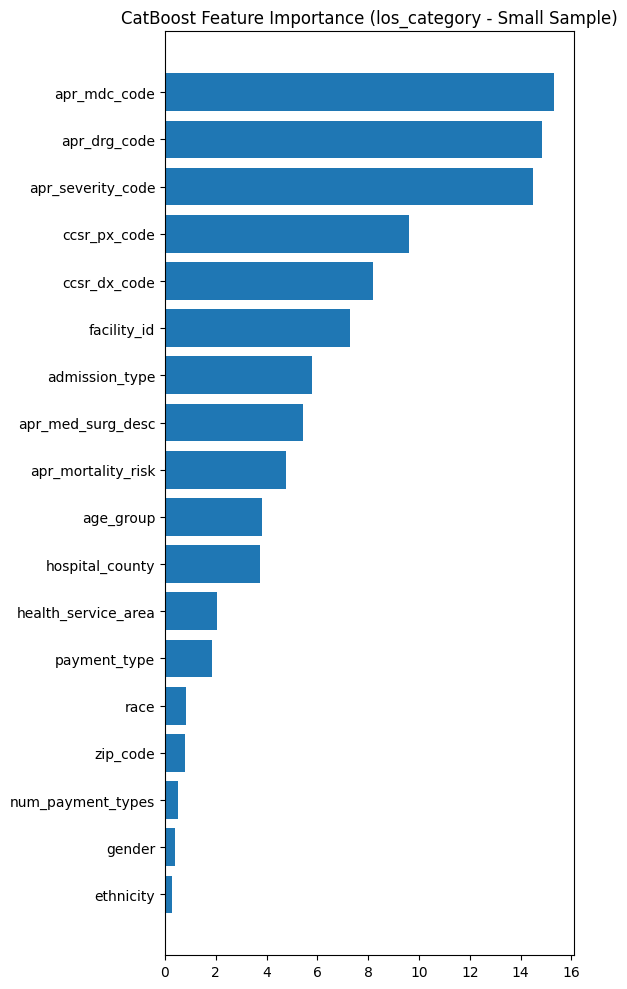

In [26]:
#Feature Importance
import matplotlib.pyplot as plt

feature_importances_cls = cls_model_small.get_feature_importance()
feature_names_cls = X_train_small_cls.columns

sorted_idx_cls = np.argsort(feature_importances_cls)

plt.figure(figsize=(6, 10))
plt.barh(feature_names_cls[sorted_idx_cls], feature_importances_cls[sorted_idx_cls])
plt.title("CatBoost Feature Importance (los_category - Small Sample)")
plt.tight_layout()
plt.show()


# Socio Comparison for Categorical

In [27]:
from catboost import CatBoostClassifier

# socio-economic features to drop
soc_cols = ["zip_code", "race", "ethnicity", "payment_type"]
soc_cols = [c for c in soc_cols if c in X_train_small_cls.columns]
print("Socio-economic columns:", soc_cols)

# New X without socio features
X_train_small_cls_nosoc = X_train_small_cls.drop(columns=soc_cols)
X_test_small_cls_nosoc  = X_test_small_cls.drop(columns=soc_cols)

# New categorical feature list for this model
cat_features_cls_nosoc = [c for c in cat_features_cls if c in X_train_small_cls_nosoc.columns]
print("Cat features (no socio):", cat_features_cls_nosoc)

# Model B: WITHOUT socio-economic features
cls_model_small_nosoc = CatBoostClassifier(
    depth=6,
    learning_rate=0.1,
    iterations=500,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=50,
    task_type="GPU",   # keep if you were using GPU
    devices="0"
)

cls_model_small_nosoc.fit(
    X_train_small_cls_nosoc,
    y_train_small_cls,
    cat_features=cat_features_cls_nosoc,
    eval_set=(X_test_small_cls_nosoc, y_test_small_cls),
    use_best_model=True
)


Socio-economic columns: ['zip_code', 'race', 'ethnicity', 'payment_type']
Cat features (no socio): ['health_service_area', 'hospital_county', 'facility_id', 'age_group', 'gender', 'admission_type', 'ccsr_dx_code', 'ccsr_px_code', 'apr_drg_code', 'apr_mdc_code', 'apr_severity_code', 'apr_mortality_risk', 'apr_med_surg_desc']
0:	learn: 0.4888104	test: 0.4885852	best: 0.4885852 (0)	total: 21.2ms	remaining: 10.6s
50:	learn: 0.5423385	test: 0.5437523	best: 0.5437523 (50)	total: 800ms	remaining: 7.04s
100:	learn: 0.5538955	test: 0.5541409	best: 0.5542038 (97)	total: 1.49s	remaining: 5.9s
150:	learn: 0.5587117	test: 0.5573652	best: 0.5573652 (150)	total: 2.19s	remaining: 5.07s
200:	learn: 0.5616304	test: 0.5586156	best: 0.5587493 (198)	total: 2.85s	remaining: 4.24s
250:	learn: 0.5638246	test: 0.5597008	best: 0.5597008 (250)	total: 3.54s	remaining: 3.52s
300:	learn: 0.5652940	test: 0.5604401	best: 0.5605187 (295)	total: 4.32s	remaining: 2.86s
350:	learn: 0.5670331	test: 0.5606131	best: 0.56081

In [28]:
import numpy as np
from collections import Counter

# Predictions for Model B
y_train_pred_cls_nosoc = cls_model_small_nosoc.predict(X_train_small_cls_nosoc)
y_test_pred_cls_nosoc  = cls_model_small_nosoc.predict(X_test_small_cls_nosoc)

print("\n=== Model B: WITHOUT socio-economic features ===")
print("Train accuracy:", accuracy_score(y_train_small_cls, y_train_pred_cls_nosoc))
print("Test accuracy :", accuracy_score(y_test_small_cls, y_test_pred_cls_nosoc))
print()
print("Test classification report (Model B):")
print(classification_report(y_test_small_cls, y_test_pred_cls_nosoc))

# Baseline: always predict majority class
most_common_class = Counter(y_train_small_cls).most_common(1)[0][0]
baseline_pred_test = np.full_like(y_test_small_cls, most_common_class, dtype=object)

baseline_acc = accuracy_score(y_test_small_cls, baseline_pred_test)

print("=== Baseline (majority class) ===")
print("Most common class:", most_common_class)
print("Baseline test accuracy:", baseline_acc)



=== Model B: WITHOUT socio-economic features ===
Train accuracy: 0.5713303494391717
Test accuracy : 0.5626656390817795

Test classification report (Model B):
              precision    recall  f1-score   support

     Extreme       0.57      0.57      0.57     16149
        Long       0.38      0.21      0.27     20850
    Moderate       0.47      0.53      0.50     40388
       Short       0.68      0.73      0.71     49772

    accuracy                           0.56    127159
   macro avg       0.53      0.51      0.51    127159
weighted avg       0.55      0.56      0.55    127159

=== Baseline (majority class) ===
Most common class: Short
Baseline test accuracy: 0.39141547196816584
